In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("C:/Users/JAAVANIKA L/fall semester 22-23/Downloads/heart.csv")

In [3]:
X = data.drop('target', axis=1)  # all columns except target
y = data['target'] 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

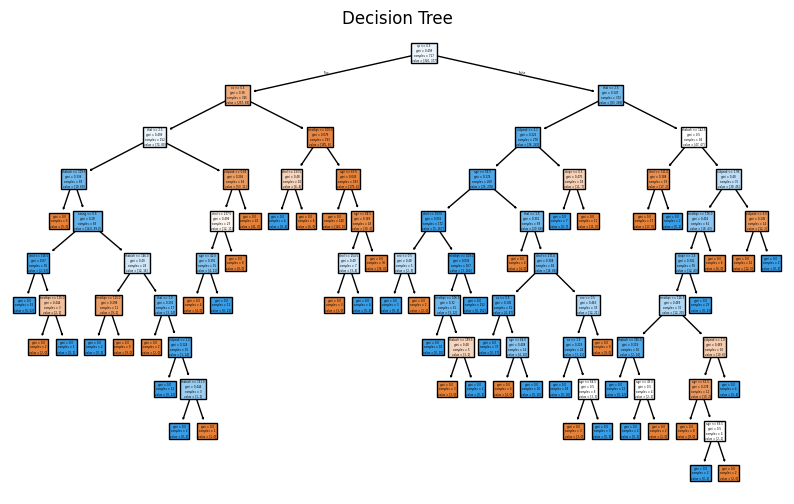

In [6]:
plt.figure(figsize=(10, 6))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.title("Decision Tree")
plt.show()

In [7]:
dt_preds = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))

Decision Tree Accuracy: 0.9707792207792207


In [8]:
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_train, y_train)
limited_preds = dt_limited.predict(X_test)
print("Limited Depth Accuracy:", accuracy_score(y_test, limited_preds))

Limited Depth Accuracy: 0.8051948051948052


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))


Random Forest Accuracy: 0.9805194805194806


In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
print("\nFeature Importances:\n", importances.sort_values(ascending=False))


Feature Importances:
 cp          0.132274
thalach     0.125039
ca          0.122912
oldpeak     0.122852
thal        0.113005
age         0.085554
chol        0.079872
trestbps    0.068356
slope       0.051335
exang       0.042210
sex         0.028721
restecg     0.018155
fbs         0.009714
dtype: float64


In [11]:
dt_cv = cross_val_score(dt, X, y, cv=5).mean()
rf_cv = cross_val_score(rf, X, y, cv=5).mean()
print("\nCV Accuracy (Decision Tree):", dt_cv)
print("CV Accuracy (Random Forest):", rf_cv)


CV Accuracy (Decision Tree): 1.0
CV Accuracy (Random Forest): 0.9970731707317073
